# Predict diabetes subtype classification
Analysis of pre-COVID19 UAB data by diabetes subtype classification showed racial differences in cluster distribution. Map cluster assignments from UAB data to NHANES data.

**Objective:** Assign clusters using generated random forest model to NHANES data.

# Environment setup
Import required modules.

In [1]:
import numpy as np
import pandas as pd

import joblib

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

Load pre-trained random forest model to assign clusters.

In [2]:
rf_path = "/data/user/brianlu/projects/precision_diabetes/cluster_prediction/exports/models/full_linear_rf_model.joblib"

rf = joblib.load(rf_path)

Linear approximation of HOMA (HOMA1) is written as

$$ 
B = \frac{20 * insulin}{glucose-3.5}
$$

$$
IR =\frac{glucose * insulin}{22.5}
$$

where glucose is in mmol/L and insulin is in $\mu$IU/mL. LBDINSI is in pmol/L and LBDGLUSI is in mmol/L. Insulin conversion rate of 6 pmol/L = 1 $\mu$IU/mL was used as defined in NHANES analytical guidelines. As such, HOMA will be approximated as 

$$ 
B = \frac{20 * \frac{insulin}{6}}{glucose-3.5}
$$

$$
IR =\frac{glucose * \frac{insulin}{6}}{22.5}
$$

However, HOMA values calculated from insulin and c-peptide values are not directly interchangable. Linear mixed-effects model was used to fit HOMA1 estimates calcualted from insulin to HOMA1 estimates calculated from c-peptide. See R Markdown for details.

Set up label encoder to convert numbered clusters to named clusters.

In [3]:
# multiple classes to predict, transform into labels
le = LabelEncoder()
le.fit(np.array(["SAID", "SIDD", "SIRD", "MOD", "MARD"]))
le.classes_ = np.array(["SAID", "SIDD", "SIRD", "MOD", "MARD"])

# Data cleaning
Load NHANES data.

In [4]:
data_path = "../exports/NHANES/nhanes_clustering_features.csv"

data = pd.read_csv(data_path)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1714 entries, 0 to 1713
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   SEQN               1714 non-null   int64  
 1   cycle              1714 non-null   object 
 2   DIQ010             1714 non-null   object 
 3   LBXGH              1714 non-null   float64
 4   BMXBMI             1714 non-null   float64
 5   RIDAGEYR           1714 non-null   int64  
 6   LBDINSI            1714 non-null   float64
 7   LBDGLUSI           1714 non-null   float64
 8   homa1_cpeptide_b   1714 non-null   float64
 9   homa1_cpeptide_ir  1714 non-null   float64
dtypes: float64(6), int64(2), object(2)
memory usage: 134.0+ KB


Remove rows with missing data in the 5 features for clustering.

In [5]:
clustering_features = ["LBXGH", "BMXBMI", "RIDAGEYR", "homa1_cpeptide_b", "homa1_cpeptide_ir"]

data_no_na = data.dropna(subset = clustering_features,
                       axis = 0)

Respondents must be medically diagnosed with diabetes or meet diagnostic criteria for diabetes.

In [6]:
data_no_na = data_no_na[(data_no_na["DIQ010"] == "Yes") | 
                                (data_no_na["LBXGH"] >= 6.5) | 
                                (data_no_na["LBDGLUSI"] >= 7)]

print(f"Number of respondents: {data_no_na.shape[0]}")

Number of respondents: 1714


Respondents under 18 at the time of diabetes diagnoses were already removed similar to [Ahlqvist et al.](https://doi.org/10.1016/s2213-8587(18)30051-2). Also remove survey respondents under 18 at the time of survey.

In [7]:
data_no_na = data_no_na[data_no_na["RIDAGEYR"] >= 18]

print(f"Number of respondents: {data_no_na.shape[0]}")

Number of respondents: 1714


Defined function to remove outliers based on number of standard deviations from mean.

In [8]:
# remove outliers by z score
def remove_outlier(df, feature, distance):
    upper = []
    lower = []
    
    # find upper and lower bounds that defines an outlier for each feature
    for f in feature:
        upper.append(df[f].mean() + distance * df[f].std())
        lower.append(df[f].mean() - distance * df[f].std())
    
    # subset df to only values within the outlier boundaries
    for i in range(len(upper)):
        df = df[(df[feature[i]] < upper[i]) & (df[feature[i]] > lower[i])]
    return df

Outliers from each feature were removed. Outliers were defined as values greater than 5 standard deviations from the mean same as used by [Ahlqvist et al.](https://doi.org/10.1016/s2213-8587(18)30051-2)

In [9]:
# remove outliers outpatient data and print number of rows removed
data_cleaned = remove_outlier(data_no_na, clustering_features, 5)
rows_removed = data_no_na.shape[0] - data_cleaned.shape[0]

print(f"{rows_removed} respondent(s) removed as outliers.")
print(f"Number of respondents: {data_cleaned.shape[0]}")

5 respondent(s) removed as outliers.
Number of respondents: 1709


Since GAD autoantibodies were not measured, the SAID cluster was impossible to identify. However, since SAID largely represents type 1 diabetes and generally only accounts for a small percentage of the clusters, it was not relevant for this type 2 diabetes focused study.

Check that feature values look reasonable.

In [10]:
data_cleaned[clustering_features].describe()

,LBXGH,BMXBMI,RIDAGEYR,homa1_cpeptide_b,homa1_cpeptide_ir
count,1709.000000,1709.000000,1709.000000,1709.000000,1709.000000
mean,7.246226,32.630895,61.485079,32.523643,1.906761
std,1.663013,7.459040,12.857644,25.153336,1.030968
min,4.400000,16.400000,18.000000,2.202734,0.426212
25%,6.200000,27.500000,54.000000,15.939012,1.155978
50%,6.700000,31.300000,63.000000,25.995937,1.650569
75%,7.800000,36.300000,71.000000,41.470617,2.398766
max,15.400000,67.000000,80.000000,253.275802,6.942967


# Cluster assignment
Use model to assign clusters.

In [11]:
predictors = ["gad", "a1c", "bmi", "diabetes_age", "homa1_cpeptide_b", "homa1_cpeptide_ir"]

# impute gad as negative
data_cleaned["gad"] = 0

# temporarily add features to match model feature names
data_cleaned["a1c"] = data_cleaned["LBXGH"]
data_cleaned["bmi"] = data_cleaned["BMXBMI"]
data_cleaned["diabetes_age"] = data_cleaned["RIDAGEYR"]

# assign cluster based on trained model
mapped_clusters = rf.predict(data_cleaned[predictors])

# convert encoded labels back to cluster names
mapped_clusters = le.inverse_transform(mapped_clusters)

# insert back into data
data_cleaned["mapped_cluster"] = mapped_clusters

In [12]:
data_cleaned[predictors].describe()

,gad,a1c,bmi,diabetes_age,homa1_cpeptide_b,homa1_cpeptide_ir
count,1709.0,1709.000000,1709.000000,1709.000000,1709.000000,1709.000000
mean,0.0,7.246226,32.630895,61.485079,32.523643,1.906761
std,0.0,1.663013,7.459040,12.857644,25.153336,1.030968
min,0.0,4.400000,16.400000,18.000000,2.202734,0.426212
25%,0.0,6.200000,27.500000,54.000000,15.939012,1.155978
50%,0.0,6.700000,31.300000,63.000000,25.995937,1.650569
75%,0.0,7.800000,36.300000,71.000000,41.470617,2.398766
max,0.0,15.400000,67.000000,80.000000,253.275802,6.942967


Clusters have similar feature distribution as [Lu et al.](https://doi.org/10.1210/clinem/dgae516)

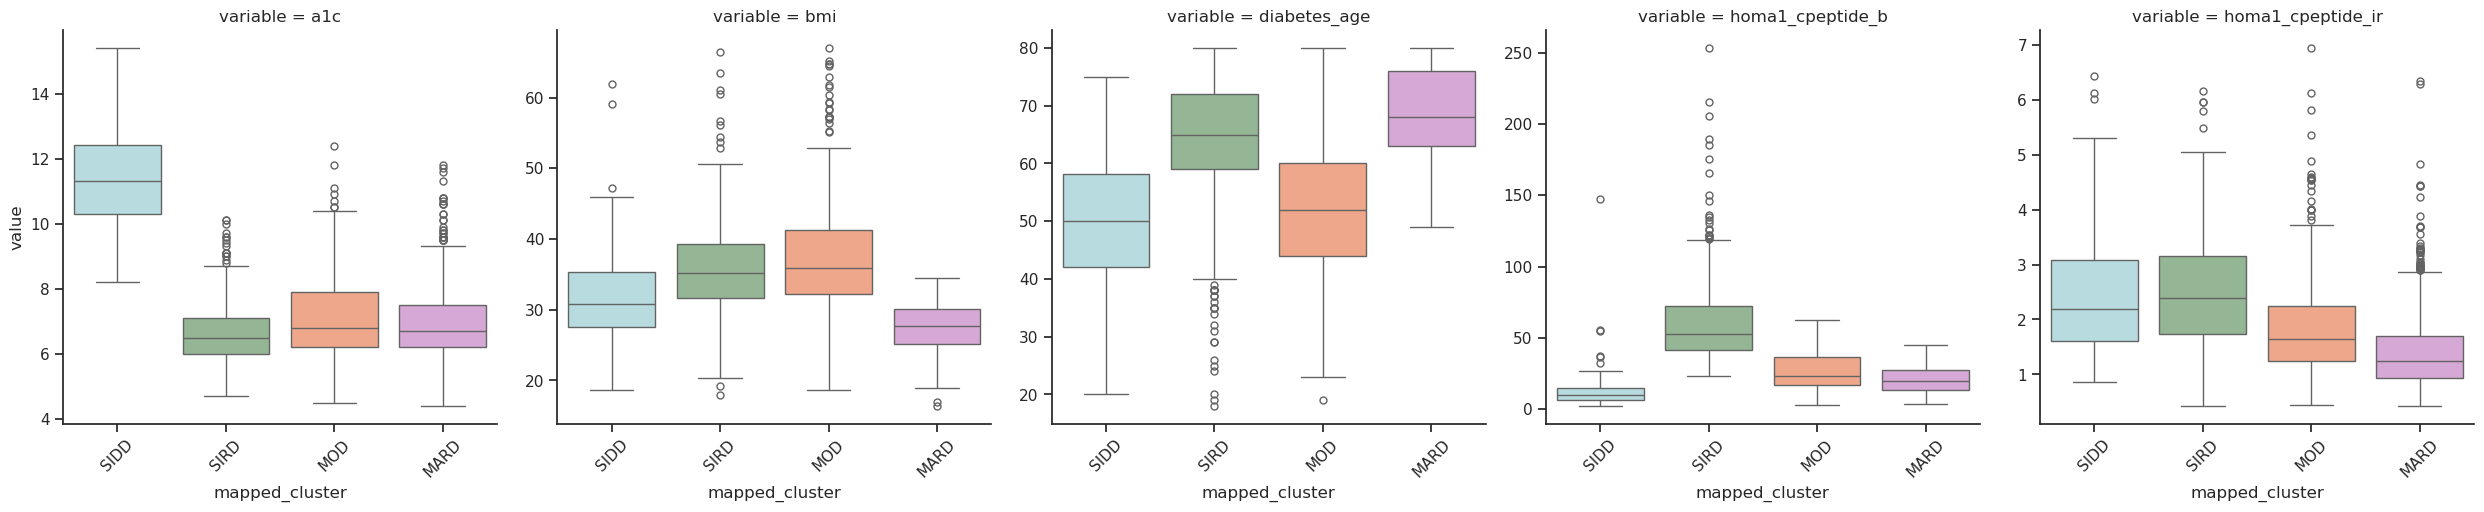

In [13]:
import seaborn as sns
sns.set(font_scale = 1, style = "ticks")
# convert data to long form for graphing[
data_long = data_cleaned.melt(id_vars = "mapped_cluster", 
                                                   value_vars = ["a1c", "bmi", "diabetes_age", 
                                                                 "homa1_cpeptide_b", "homa1_cpeptide_ir"])

# plot features by cluster
color = ["powderblue", "darkseagreen", "lightsalmon", "plum"]
order = ["SIDD", "SIRD", "MOD", "MARD"]

sns.catplot(data = data_long, 
            x = "mapped_cluster", 
            y = "value", 
            col = "variable", 
            col_wrap = 5, 
            kind = "box", 
            sharey = False,
            order = order,
            hue = "mapped_cluster",
            palette = {key: value for key, value in zip(order, color)}
           ).set_xticklabels(labels = order, rotation = 45);

In [14]:
data_cleaned = data_cleaned[["SEQN", "homa1_cpeptide_b", "homa1_cpeptide_ir", "mapped_cluster"]].copy()

# Export results

Create export directory.

In [15]:
from watermark import watermark
import os

# define export directory
export_dir_path = "../exports/NHANES/"

# create export directory if folder doesn't exist
if not os.path.isdir(export_dir_path):
    os.mkdir(export_dir_path)

Export results.

In [16]:
data_cleaned.to_csv(export_dir_path + "nhanes_mapped_clusters.csv", index = False)

In [17]:
print(watermark())

Last updated: 2025-06-28T17:07:55.865153-05:00

Python implementation: CPython
Python version       : 3.12.6
IPython version      : 8.27.0

Compiler    : GCC 13.3.0
OS          : Linux
Release     : 3.10.0-1160.24.1.el7.x86_64
Machine     : x86_64
Processor   : x86_64
CPU cores   : 48
Architecture: 64bit

